In [18]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

sales = pd.read_csv("../data/sales_daily.csv")

sales["Date"] = pd.to_datetime(sales["Date"])

print("Dataset shape:", sales.shape)
print(sales.head())

Dataset shape: (36550, 6)
        Date     SKU  Units_Sold    Revenue    Price  Promotion
0 2024-01-01  SKU001           5   18320.25  3664.05          0
1 2024-01-01  SKU002          15   57085.35  3805.69          0
2 2024-01-01  SKU003           5   40391.15  8078.23          0
3 2024-01-01  SKU004           5   34307.85  6861.57          0
4 2024-01-01  SKU005          12  113918.64  9493.22          0


## Convert daily sales into weekly de

In [19]:
weekly_sales = (
    sales.groupby("SKU")
    .resample("W", on="Date")["Units_Sold"]
    .sum()
    .reset_index()
)

weekly_sales = weekly_sales[
    weekly_sales["Date"] < "2026-01-04"
].copy()

print("Weekly dataset shape:", weekly_sales.shape)
print(weekly_sales.head())

Weekly dataset shape: (5200, 3)
      SKU       Date  Units_Sold
0  SKU001 2024-01-07         106
1  SKU001 2024-01-14          85
2  SKU001 2024-01-21         117
3  SKU001 2024-01-28          89
4  SKU001 2024-02-04         119


## Create forecasting features

In [20]:
weekly_sales = weekly_sales.sort_values(
    ["SKU", "Date"]
).copy()

weekly_sales["lag_1"] = weekly_sales.groupby("SKU")["Units_Sold"].shift(1)

weekly_sales["lag_4"] = weekly_sales.groupby("SKU")["Units_Sold"].shift(4)

weekly_sales["rolling_mean_4"] = weekly_sales.groupby("SKU")["Units_Sold"].transform(
    lambda x: x.shift(1).rolling(4).mean()
)

weekly_sales["lag_52"] = weekly_sales.groupby("SKU")["Units_Sold"].shift(52)

print(weekly_sales.head(10))

      SKU       Date  Units_Sold  lag_1  lag_4  rolling_mean_4  lag_52
0  SKU001 2024-01-07         106    NaN    NaN             NaN     NaN
1  SKU001 2024-01-14          85  106.0    NaN             NaN     NaN
2  SKU001 2024-01-21         117   85.0    NaN             NaN     NaN
3  SKU001 2024-01-28          89  117.0    NaN             NaN     NaN
4  SKU001 2024-02-04         119   89.0  106.0           99.25     NaN
5  SKU001 2024-02-11         112  119.0   85.0          102.50     NaN
6  SKU001 2024-02-18         104  112.0  117.0          109.25     NaN
7  SKU001 2024-02-25         120  104.0   89.0          106.00     NaN
8  SKU001 2024-03-03         103  120.0  119.0          113.75     NaN
9  SKU001 2024-03-10         119  103.0  112.0          109.75     NaN


In [21]:
feature_columns = [
    "lag_1",
    "lag_4",
    "rolling_mean_4",
    "lag_52"
]

feature_data = weekly_sales.dropna(
    subset=feature_columns
).copy()

print("Feature dataset shape:", feature_data.shape)
print("First available date:", feature_data["Date"].min())
print("Last available date:", feature_data["Date"].max())

Feature dataset shape: (2600, 7)
First available date: 2025-01-05 00:00:00
Last available date: 2025-12-28 00:00:00


In [22]:
test_dates = sorted(feature_data["Date"].unique())[-12:]

print("Number of test weeks:", len(test_dates))
print("First test date:", test_dates[0])
print("Last test date:", test_dates[-1])

Number of test weeks: 12
First test date: 2025-10-12 00:00:00
Last test date: 2025-12-28 00:00:00


In [23]:
print("Feature data:", feature_data.shape)
print("Weekly data:", weekly_sales.shape)

Feature data: (2600, 7)
Weekly data: (5200, 7)


## Create the backtesting loop

In [24]:
feature_columns = [
    "lag_1",
    "lag_4",
    "rolling_mean_4",
    "lag_52"
]

test_dates = sorted(feature_data["Date"].unique())[-12:]

backtest_results = []

for forecast_date in test_dates:

    train = feature_data[
        feature_data["Date"] < forecast_date
    ]

    test = feature_data[
        feature_data["Date"] == forecast_date
    ]

    model = RandomForestRegressor(
        n_estimators=100,
        random_state=42
    )

    model.fit(
        train[feature_columns],
        train["Units_Sold"]
    )

    predictions = model.predict(test[feature_columns])

    for i in range(len(test)):
        backtest_results.append({
            "SKU": test.iloc[i]["SKU"],
            "Date": forecast_date,
            "Actual": test.iloc[i]["Units_Sold"],
            "RF_Forecast": predictions[i],
            "Seasonal_Forecast": test.iloc[i]["lag_52"]
        })

print("Backtesting completed!")
print("Total predictions:", len(backtest_results))

Backtesting completed!
Total predictions: 600


In [25]:
backtest_df = pd.DataFrame(backtest_results)

print("Backtest dataset shape:", backtest_df.shape)

print(backtest_df.head(10))

Backtest dataset shape: (600, 5)
      SKU       Date  Actual  RF_Forecast  Seasonal_Forecast
0  SKU001 2025-10-12      82        74.71               82.0
1  SKU002 2025-10-12      56        67.83               65.0
2  SKU003 2025-10-12      33        38.60               34.0
3  SKU004 2025-10-12      28        24.65               29.0
4  SKU005 2025-10-12     107        96.54               96.0
5  SKU006 2025-10-12      38        42.57               38.0
6  SKU007 2025-10-12     149       138.72              123.0
7  SKU008 2025-10-12      88        87.92               80.0
8  SKU009 2025-10-12      51        72.59               65.0
9  SKU010 2025-10-12      83        87.50               79.0


In [26]:
backtest_df["RF_Absolute_Error"] = (
    backtest_df["Actual"] - backtest_df["RF_Forecast"]
).abs()

backtest_df["Seasonal_Absolute_Error"] = (
    backtest_df["Actual"] - backtest_df["Seasonal_Forecast"]
).abs()

print(backtest_df.head(10))

      SKU       Date  Actual  RF_Forecast  Seasonal_Forecast  \
0  SKU001 2025-10-12      82        74.71               82.0   
1  SKU002 2025-10-12      56        67.83               65.0   
2  SKU003 2025-10-12      33        38.60               34.0   
3  SKU004 2025-10-12      28        24.65               29.0   
4  SKU005 2025-10-12     107        96.54               96.0   
5  SKU006 2025-10-12      38        42.57               38.0   
6  SKU007 2025-10-12     149       138.72              123.0   
7  SKU008 2025-10-12      88        87.92               80.0   
8  SKU009 2025-10-12      51        72.59               65.0   
9  SKU010 2025-10-12      83        87.50               79.0   

   RF_Absolute_Error  Seasonal_Absolute_Error  
0               7.29                      0.0  
1              11.83                      9.0  
2               5.60                      1.0  
3               3.35                      1.0  
4              10.46                     11.0  
5      

In [27]:
rf_mae = backtest_df["RF_Absolute_Error"].mean()

seasonal_mae = backtest_df["Seasonal_Absolute_Error"].mean()

rf_wape = (
    backtest_df["RF_Absolute_Error"].sum()
    / backtest_df["Actual"].sum()
) * 100

seasonal_wape = (
    backtest_df["Seasonal_Absolute_Error"].sum()
    / backtest_df["Actual"].sum()
) * 100

print("Rolling-Origin Backtest Results")
print("--------------------------------")
print("Random Forest MAE:", rf_mae)
print("Random Forest WAPE:", rf_wape, "%")
print("Seasonal Naive MAE:", seasonal_mae)
print("Seasonal Naive WAPE:", seasonal_wape, "%")

Rolling-Origin Backtest Results
--------------------------------
Random Forest MAE: 8.56155
Random Forest WAPE: 10.166501741608613 %
Seasonal Naive MAE: 9.691666666666666
Seasonal Naive WAPE: 11.508470550981635 %


In [28]:
backtest_comparison = pd.DataFrame({
    "Model": ["Random Forest", "Seasonal Naive"],
    "MAE": [rf_mae, seasonal_mae],
    "WAPE (%)": [rf_wape, seasonal_wape]
})

print(backtest_comparison)

            Model       MAE   WAPE (%)
0   Random Forest  8.561550  10.166502
1  Seasonal Naive  9.691667  11.508471


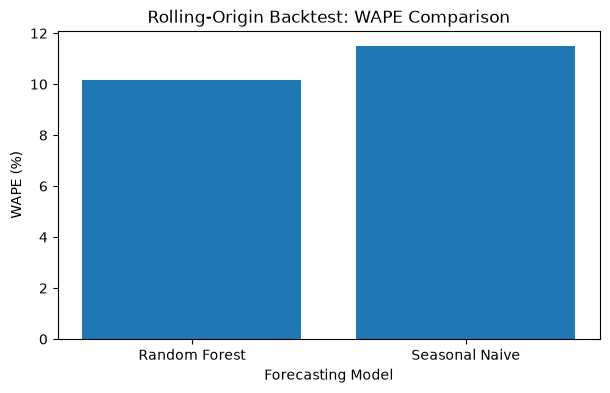

In [30]:
import matplotlib.pyplot as plt
plt.figure(figsize=(7, 4))

plt.bar(
    backtest_comparison["Model"],
    backtest_comparison["WAPE (%)"]
)

plt.title("Rolling-Origin Backtest: WAPE Comparison")
plt.xlabel("Forecasting Model")
plt.ylabel("WAPE (%)")

plt.show()

## Rolling-Origin Backtesting Results

### Evaluation Setup

* Number of SKUs: 50
* Forecasting horizon: 1 week ahead
* Evaluation period: October 12, 2025 to December 28, 2025
* Total predictions: 600
* Models: Random Forest Regressor and Seasonal Naive Baseline

### Performance Comparison

| Model          |  MAE |   WAPE |
| -------------- | ---: | -----: |
| Random Forest  | 8.56 | 10.17% |
| Seasonal Naive | 9.69 | 11.51% |

### Key Findings

* Random Forest achieved lower MAE and WAPE than the Seasonal Naive baseline on the evaluation period.
* Random Forest had an average absolute error of approximately 8.56 units per SKU-week.
* SKU-level forecasting errors vary, so individual products require further analysis.

### Conclusion

The rolling-origin evaluation provides an initial assessment of weekly demand forecasting performance. Random Forest showed lower errors than the baseline over the evaluated period.

Further validation and inventory risk analysis are required before operational deployment.
